questo notebook mostra come per 4 qubit, considerando 500 sample, stato ghz --> la fidelity classica risulta migliore per vae che per mle

# colab setup

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# import sys
# sys.path.append('/content/drive/MyDrive/statistical-qst-vae/statistical-qst-vae/src')

# Import

In [25]:
# general import:
import sys
import time
import os
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
# quantum import:
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere

In [27]:
# ML import:
import tensorflow as tf
import keras
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import sklearn
from sklearn.model_selection import train_test_split

In [28]:
# custom helper and libraries:
sys.path.append('../src')
from povm_sampling import *
from statesprep import *
from vae import *
from plots import *
from utils import *
from mle import *

# GHZ 4 qubit

# Data

Data creation:

┌───┐               
q_0: ┤ H ├──■────■────■──
     └───┘┌─┴─┐  │    │  
q_1: ─────┤ X ├──┼────┼──
          └───┘┌─┴─┐  │  
q_2: ──────────┤ X ├──┼──
               └───┘┌─┴─┐
q_3: ───────────────┤ X ├
                    └───┘

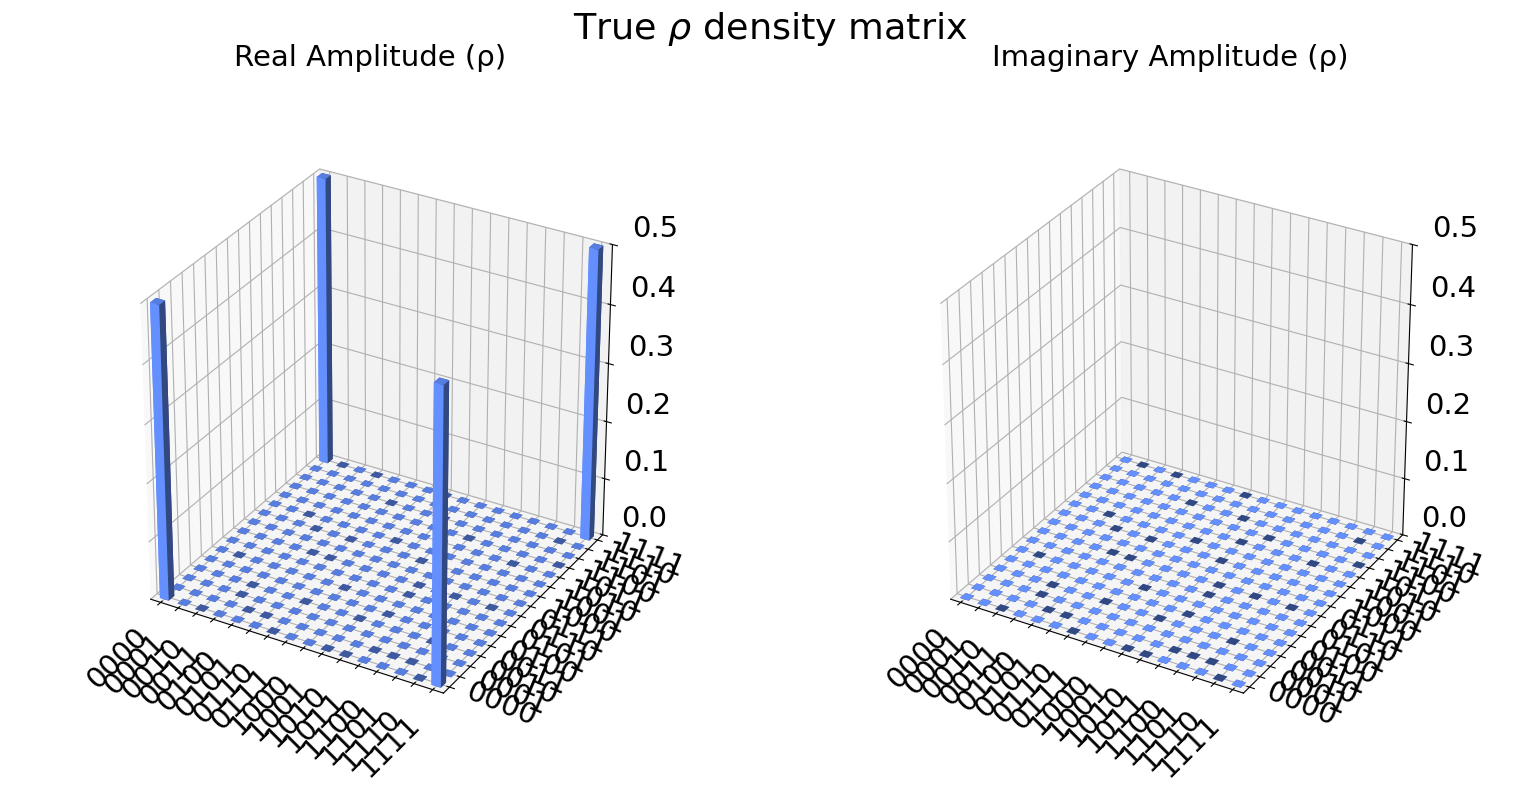

In [36]:
# true state circuit and density matrix
N = 4
qc = create_ghz_state(N)
display(qc.draw())

rho_true = DensityMatrix(qc)
fig = plot_state_city(rho_true, title="True $\\rho$ density matrix")
display(fig)

In [37]:
# create data sampling the true probability distribution
n_samples = 150
p_exact = povm_probability(rho_true.data, N)
samples = sample_povm(p_exact, n_samples)

# Direct reconstruction

Let's first try to reconstruct the matrix direcly from the inverse Born rule, using the empirical povm measurements distributions instead of the exact ones

  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  False  (min eigval = -7.38e-01)


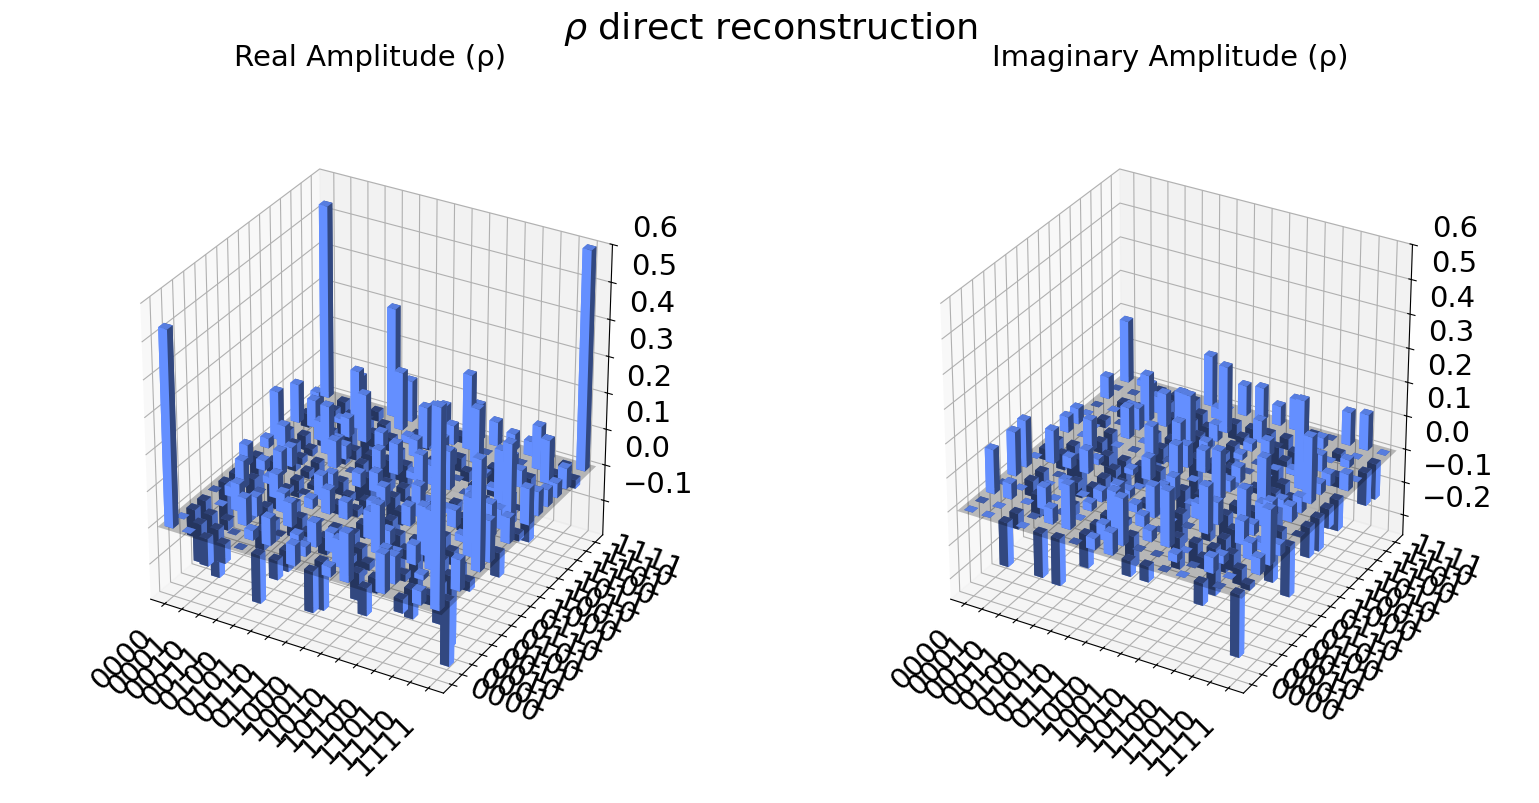

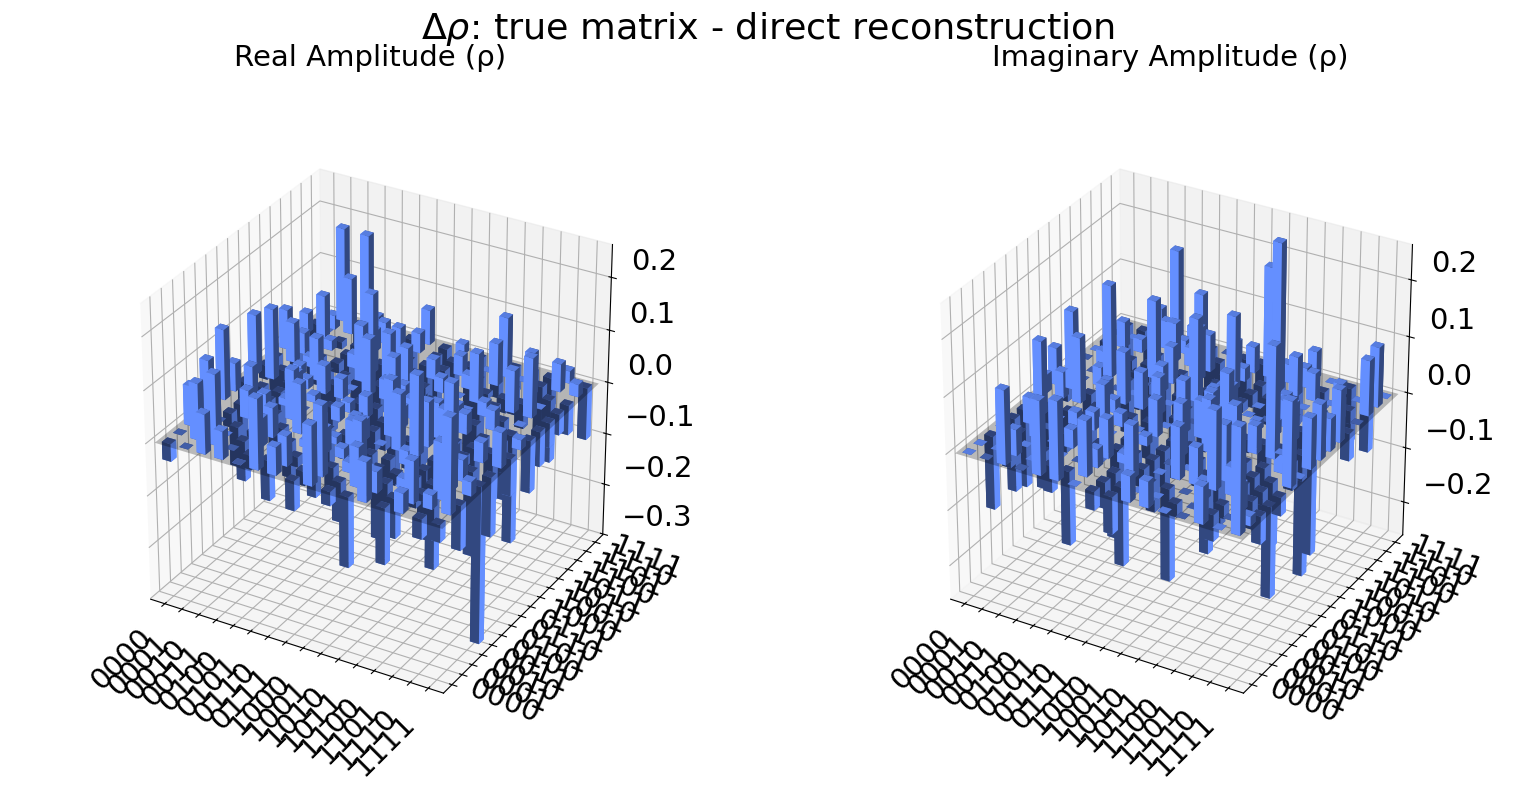

QiskitError: 'Input quantum state is not a valid'

In [38]:
# reconstruct density matrix direct from p_sample

# empirical distribution of samples
p_sample = samples_to_empirical_dist(samples, N)

# helper
povm_dict = build_povm(N)
P_vec    = pvec_from_pdict(p_sample, N)
T, T_inv = get_overlap_matrix(N)

# perform inverse Born's rule
rho_sample = reconstruct_rho(P_vec, N, T_inv, povm_dict)

# verify reconstructed rho
validate_rho(rho_sample)

# plots
fig = plot_state_city(rho_sample, title='$\\rho$ direct reconstruction')
display(fig)

rho_diff = rho_true - rho_sample

fig = plot_state_city(rho_diff, title="$\\Delta\\rho$: true matrix - direct reconstruction ")
display(fig)

fq = quantum_fidelity(rho_true, rho_sample)
print(f"quantum fidelity F_q = {fq:.6f}")

Direct reconstruction leads to un-physical solution.

Density matrix is not semi-pos


Costraint: the possible density matrix must be hermitian, semi-pos

 # Maximum Likelihood Estimator

MLE searches for the best matrix (under constraint) that can be related to the seen samples.

It uses the Cholesky matrix parametrization T(t) to ensure rho semi-pos, hermitian.

It takes $\sim$ 5min

In [39]:
# compute density matrix using MLE

# Negative LogLikelihood
nll = make_nll(samples, N)


# creates cholesky params array to initialize minuit
dim = 2**N
init_rho = np.eye(dim, dtype=complex) / dim   # max mixed state
p0 = rho_to_params(init_rho, N)
print(f"Cholesky params to minimize: {count_params(N)}  (= (2^N)^2 )")
print(len(p0), dim**2)


# create Minuit obj
m = Minuit(nll, *p0)
# iminuit built-in to use custom likelihood cost func --> for error estimation m.minos
m.errordef = Minuit.LIKELIHOOD   # = 0.5
m.print_level = 0

m.migrad()
if not m.valid:
    print('not valid!')
    # second try
    m.migrad()
else:
    print('minimization completed!')
print(f"\nMinuit valid:  {m.valid}")

Cholesky params to minimize: 256  (= (2^N)^2 )
256 256
minimization completed!

Minuit valid:  True


  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  True  (min eigval = -1.04e-17)


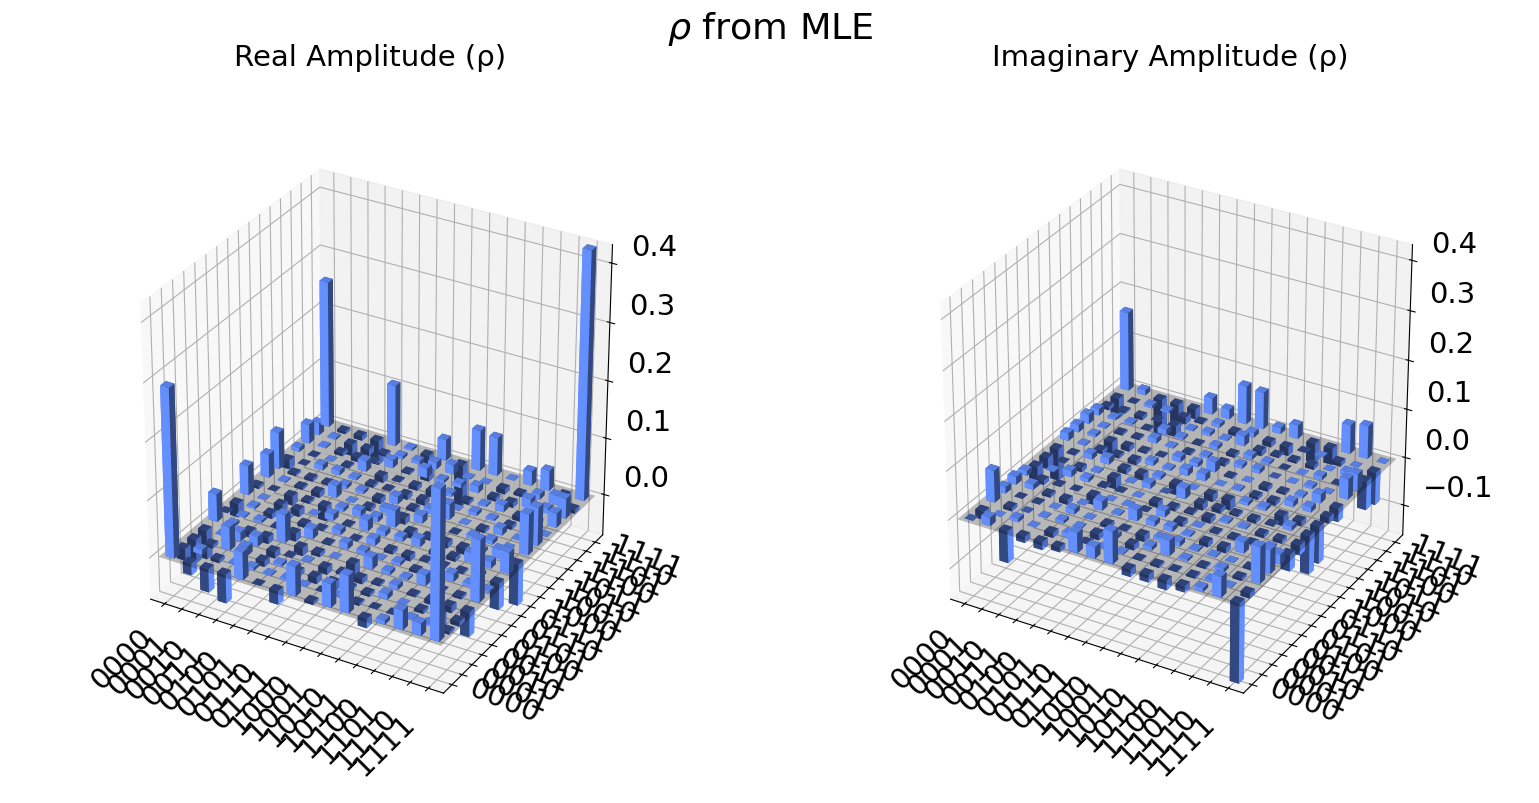

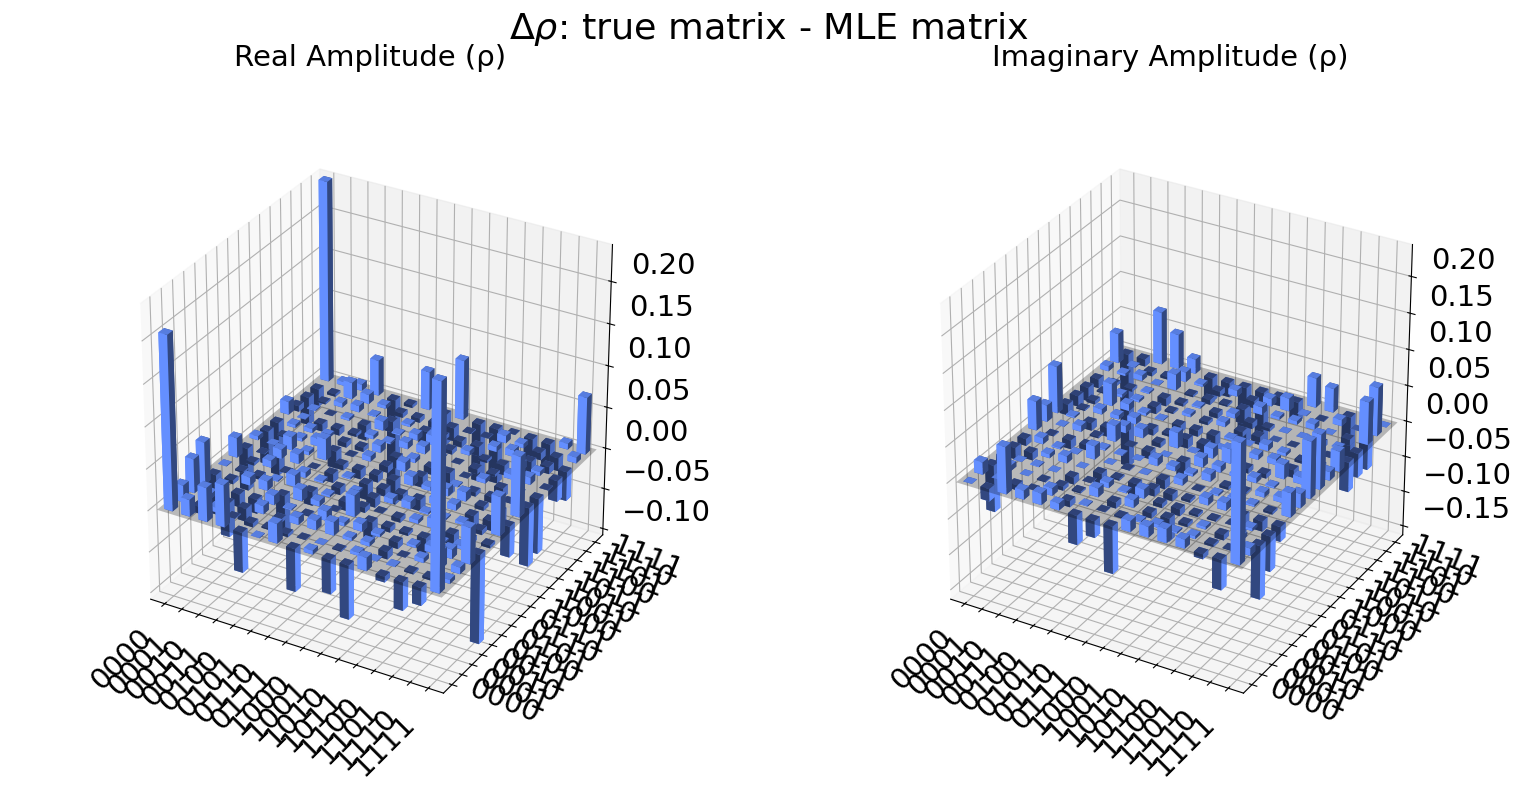

In [40]:
# reconstruct matrix after minimization:
rho_mle = params_to_rho(np.array(m.values), N)

validate_rho(rho_mle)

fig = plot_state_city(rho_mle, title='$\\rho$ from MLE')
display(fig)

rho_diff = rho_true - rho_mle

fig = plot_state_city(rho_diff, title="$\\Delta\\rho$: true matrix - MLE matrix ")
display(fig)

In [41]:
# fidelity
fq = quantum_fidelity(rho_true, rho_mle)
print(f"quantum fidelity F_q = {fq:.6f}")

# classical fidelity
p_sample = samples_to_empirical_dist(samples, N)
fc    = classical_fidelity(p_exact, p_sample)
print(f"classical fidelity (exact vs sample)  F_c  = {fc:.6f}")

p_mle = povm_probability(rho_mle, N)
# sample_from_rho_mle = sample_povm(prob_mle, 1000)
# p_mle = samples_to_empirical_dist(sample_from_rho_mle, N)
fc    = classical_fidelity(p_exact, p_mle)
print(f"classical fidelity (exact vs mle)  F_c  = {fc:.6f}")

quantum fidelity F_q = 0.618704
classical fidelity (exact vs sample)  F_c  = 0.729046
classical fidelity (exact vs mle)  F_c  = 0.966331


# Variational AutoEncoder

In [42]:
# Convert the samples to one-hot encoding
onehot_samples = samples_to_onehot(samples, N)

In [43]:
# Split the data into training and testing sets (unsupervised: no labels, no stratify)
X_train, X_test = train_test_split(onehot_samples, test_size=0.2, random_state=42)

print(f"Training set size and shape: {len(X_train)} and {X_train.shape}")
print(f"Testing set size and shape: {len(X_test)} and {X_test.shape}")

Training set size and shape: 120 and (120, 16)
Testing set size and shape: 30 and (30, 16)


## Train

In [ ]:
# da riformulare !
# PROJECT_ROOT = Path("/Users/riccardoruggeri/project-sda/statistical-qst-vae")
# RESULTS_ROOT = PROJECT_ROOT / "results"

In [55]:
# Define useful parameters for the VAE training
LATENT_DIM = 32
HIDDEN_DIM = 128
WARMUP_EPOCHS = 50
TOTAL_EPOCHS = 500
BATCH_SIZE = 200
LEARNING_RATE = 1e-3
BETA_MAX = 0.85

In [56]:
# Instantiate and compile the VAE model
vae = VAE(n_qubits=N, latent_dim=LATENT_DIM, hidden=HIDDEN_DIM)
vae.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))
vae.build(input_shape=(None, 4*N))

In [57]:
# fit:

# Define callbacks for training
callbacks = [
    KLWarmup(beta_max=BETA_MAX, warmup_epochs=WARMUP_EPOCHS),
    EarlyStopping(monitor='val_reconstruction_loss', mode='min',
                  patience=50, restore_best_weights=True,
                  start_from_epoch=WARMUP_EPOCHS),
    ReduceLROnPlateau(monitor='val_reconstruction_loss', mode='min',
                      factor=0.5, patience=20, min_lr=1e-6),
]

# fit data
history = vae.fit(
    X_train, X_train,
    epochs=TOTAL_EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, X_test),
    callbacks=callbacks,
    verbose=1,
)

# save results
# run_dir, checkpoint_path, history_path = set_up_training(experiment_id='vae_training')
# vae.save_weights(checkpoint_path)
# pd.DataFrame(history.history).to_csv(history_path, index=False)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - kl_loss: 0.5409 - kl_weight: 0.0170 - loss: 5.7067 - reconstruction_loss: 5.6975 - val_kl_loss: 0.5329 - val_loss: 5.9285 - val_reconstruction_loss: 5.9194 - learning_rate: 0.0010
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - kl_loss: 0.5398 - kl_weight: 0.0340 - loss: 5.8300 - reconstruction_loss: 5.8116 - val_kl_loss: 0.5406 - val_loss: 5.6660 - val_reconstruction_loss: 5.6477 - learning_rate: 0.0010
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - kl_loss: 0.5491 - kl_weight: 0.0510 - loss: 5.7084 - reconstruction_loss: 5.6804 - val_kl_loss: 0.5520 - val_loss: 5.4710 - val_reconstruction_loss: 5.4429 - learning_rate: 0.0010
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - kl_loss: 0.5630 - kl_weight: 0.0680 - loss: 5.6934 - reconstruction_loss: 5.6551 - val_kl_loss: 0.5667 - val_loss: 5.6161 - val_reconstruction_loss: 5.5776 - learning_rate: 0.0010
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - kl_loss: 0.5806 - kl_w

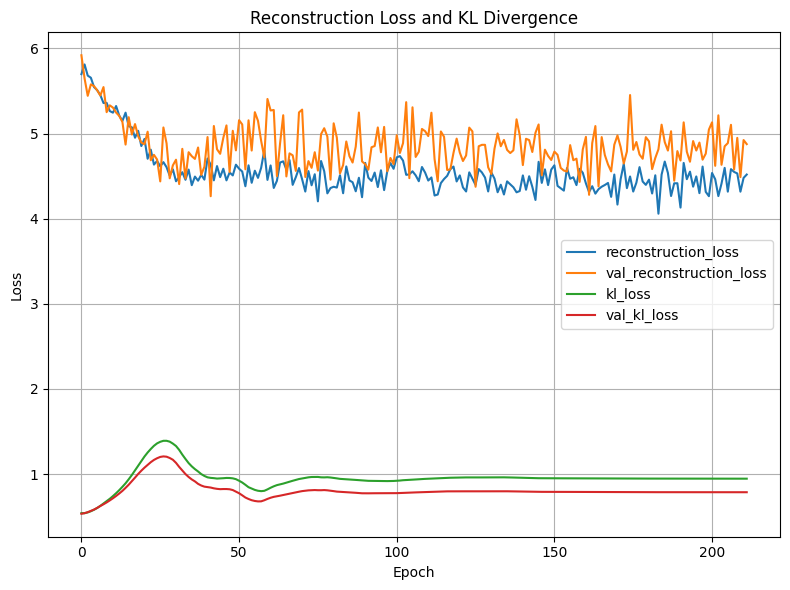

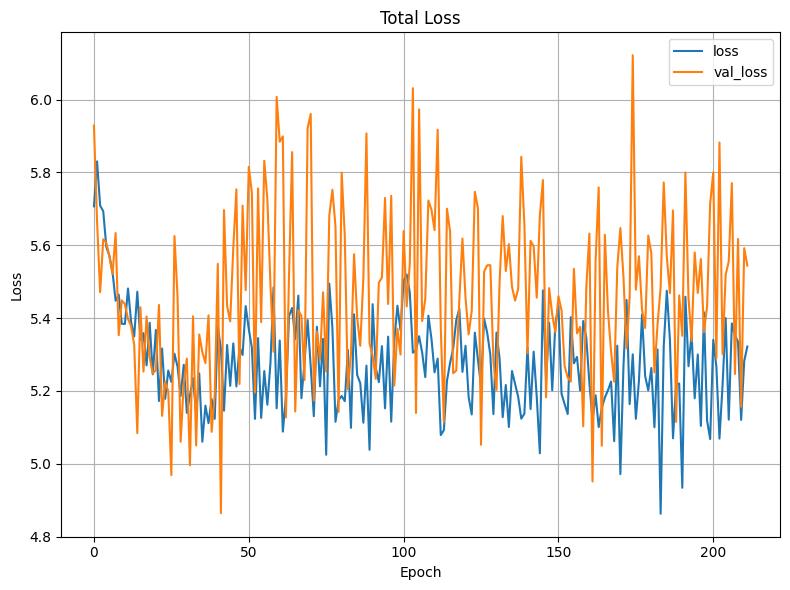

In [58]:
# Plot the training and validation loss curves
plot_reconstruction_and_kl_divergence(history)
plot_total_loss(history)

In [59]:
# fidelity and comparison

outcomes = list(p_exact.keys())

# Generate a large number of samples from the trained VAE model to estimate the distribution it has learned (p_vae)
# Convert the one-hot encoded training data back to samples and compute the empirical distribution (p_train)
p_vae   = vae.predict_dist(n_samples=1000000, batch_size=50_000)
p_unif = {o: 1.0 / len(outcomes) for o in outcomes}
p_train = samples_to_empirical_dist(onehot_to_samples(X_train, N), N)   # less then total number of samples

# Compute the classical fidelity between the distributions
classical_fidelity_floor = classical_fidelity(p_unif, p_exact)
classical_fidelity_vae = classical_fidelity(p_vae, p_exact)
classical_fidelity_train = classical_fidelity(p_train, p_exact)

print("=== Classical Fidelity ===")
print(f"  uniform  vs true : {classical_fidelity_floor:.4f}   <- FLOOR")
print(f"  VAE              vs true : {classical_fidelity_vae:.4f}   <- MODEL")
print(f"  training data    vs true : {classical_fidelity_train:.4f}   <- BASELINE\n")

print("=== GHZ 4 Peaks ===")
print(f"  {'outcome':14s} {'true':>8s} {'VAE':>8s} {'uniform':>9s}")
for o in [(c,) * N for c in range(4)]:
    print(f"  {str(o):14s} {p_exact[o]:8.7f} {p_vae.get(o, 0):8.7f} {1/len(outcomes):9.7f}")

=== Classical Fidelity ===
  uniform  vs true : 0.9209   <- FLOOR
  VAE              vs true : 0.9537   <- MODEL
  training data    vs true : 0.6809   <- BASELINE

=== GHZ 4 Peaks ===
  outcome            true      VAE   uniform
  (0, 0, 0, 0)   0.0312500 0.0190490 0.0039062
  (1, 1, 1, 1)   0.0096451 0.0086850 0.0039062
  (2, 2, 2, 2)   0.0050154 0.0054880 0.0039062
  (3, 3, 3, 3)   0.0050154 0.0025540 0.0039062


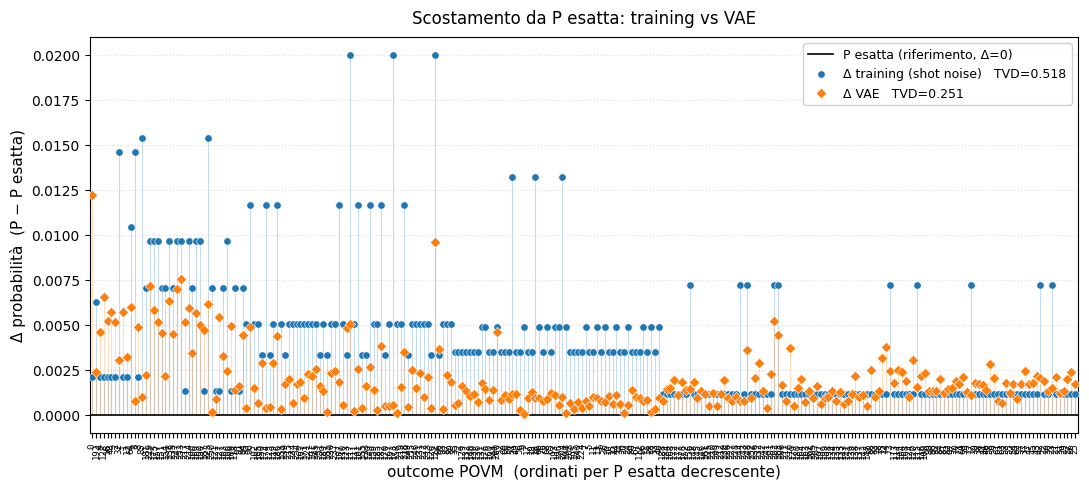

In [60]:
# Plot the distributions (p_exact, p_vae, P_train) over the outcomes
p_true = np.array([p_exact[o]        for o in outcomes])
p_gen  = np.array([p_vae.get(o, 0.0) for o in outcomes])
p_train = np.array([p_train.get(o, 0.0) for o in outcomes])
idx = np.arange(len(outcomes))

# Default abs=True
plot_distribution_delta(p_true, p_gen, p_train, idx)

Let's try to reconstruct the density matrix from the vae samples

  Hermitian:          True
  Tr(rho):            1.00000000
  Pos semi-definite:  False  (min eigval = -5.52e-02)


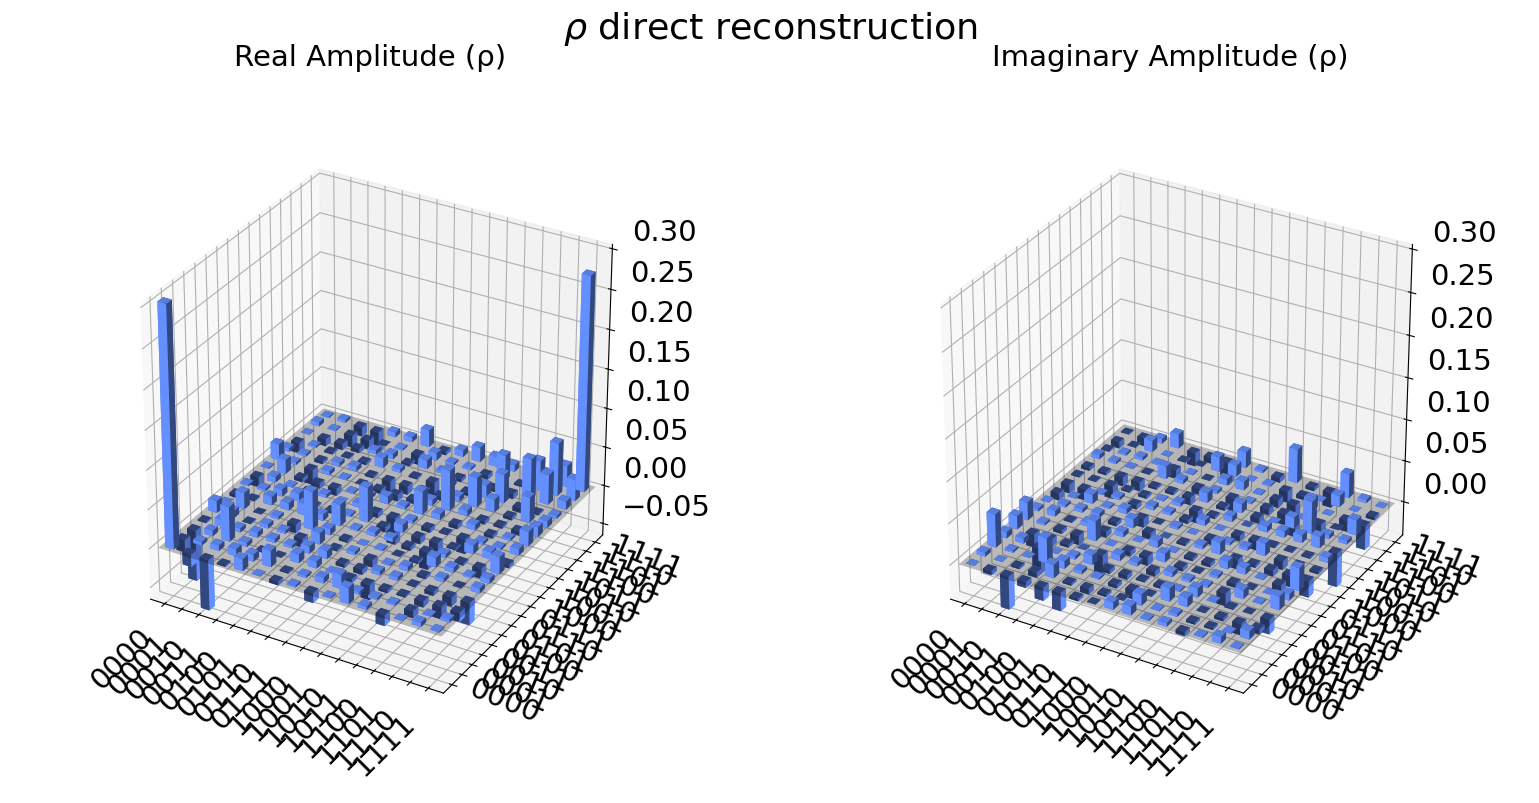

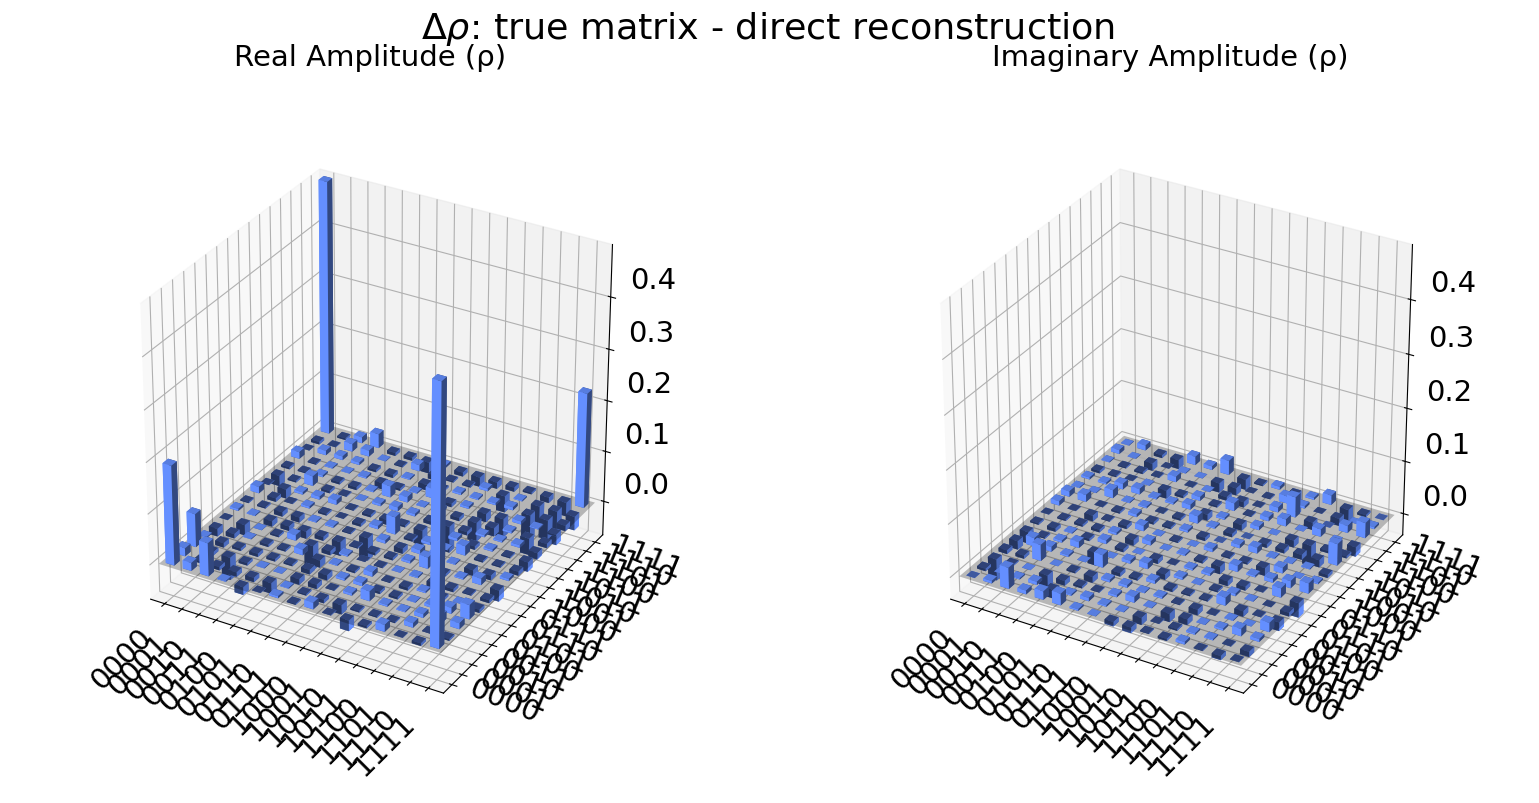

QiskitError: 'Input quantum state is not a valid'

In [46]:
# use p_vae to reconstruct the matrix

# helper
povm_dict = build_povm(N)
P_vec_vae = pvec_from_pdict(p_vae, N)
T, T_inv = get_overlap_matrix(N)

# perform inverse Born's rule
rho_vae = reconstruct_rho(P_vec_vae, N, T_inv, povm_dict)

# verify reconstructed rho
validate_rho(rho_vae)

# plots
fig = plot_state_city(rho_vae, title='$\\rho$ direct reconstruction')
display(fig)

rho_diff = rho_true - rho_vae

fig = plot_state_city(rho_diff, title="$\\Delta\\rho$: true matrix - direct reconstruction ")
display(fig)

fq = quantum_fidelity(rho_true, rho_vae)
print(f"quantum fidelity F_q = {fq:.6f}")